Loading clean MNIST model with shift augmentation...
Generating clean spatial shifts...
Epoch 1/2
5625/5625 [==============================] - 179s 32ms/step - loss: 0.0814 - accuracy: 0.9746
Epoch 2/2
5625/5625 [==============================] - 176s 31ms/step - loss: 0.0266 - accuracy: 0.9918
Scanning image file of 0


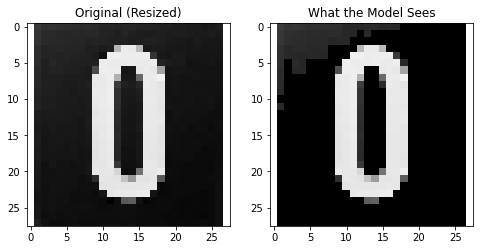

Predicted Number: 0
Confidence: 99.86%
Result Matched for 0
-------------------------------------------------------


Scanning image file of 1


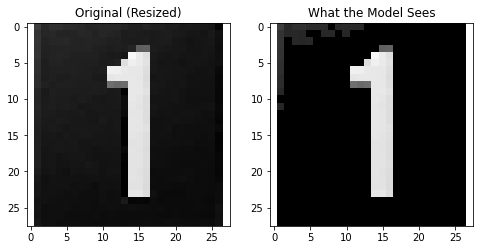

Predicted Number: 1
Confidence: 99.95%
Result Matched for 1
-------------------------------------------------------


Scanning image file of 2


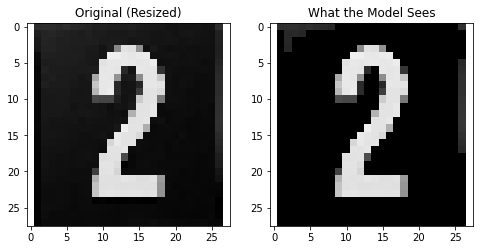

Predicted Number: 2
Confidence: 100.00%
Result Matched for 2
-------------------------------------------------------


Scanning image file of 3


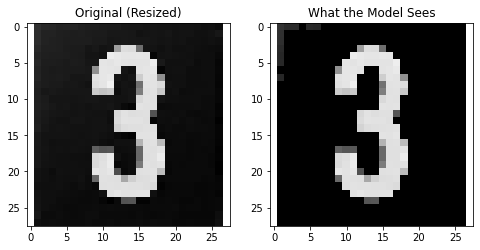

Predicted Number: 3
Confidence: 99.99%
Result Matched for 3
-------------------------------------------------------


Scanning image file of 4


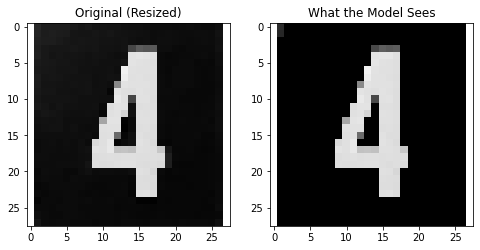

Predicted Number: 4
Confidence: 99.94%
Result Matched for 4
-------------------------------------------------------


Scanning image file of 5


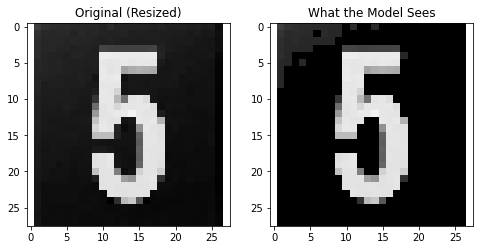

Predicted Number: 5
Confidence: 100.00%
Result Matched for 5
-------------------------------------------------------


Scanning image file of 6


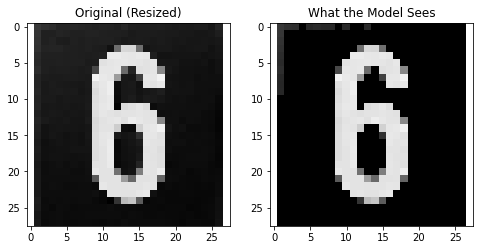

Predicted Number: 6
Confidence: 88.95%
Result Matched for 6
-------------------------------------------------------


Scanning image file of 7


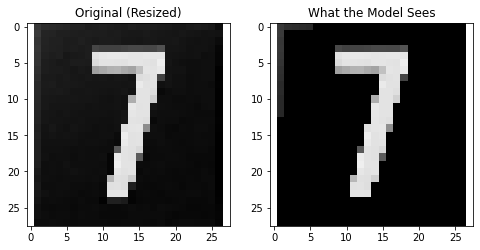

Predicted Number: 7
Confidence: 98.22%
Result Matched for 7
-------------------------------------------------------


Scanning image file of 8


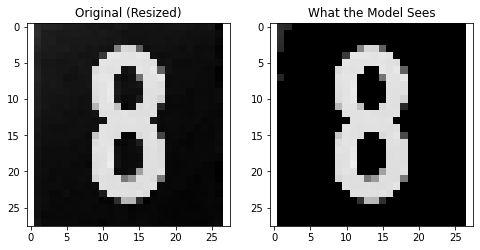

Predicted Number: 8
Confidence: 100.00%
Result Matched for 8
-------------------------------------------------------


Scanning image file of 9


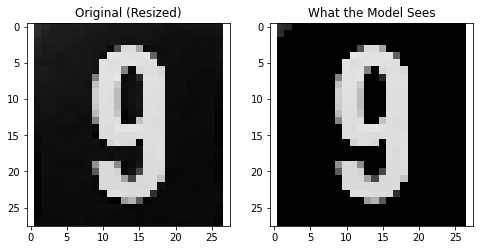

Predicted Number: 9
Confidence: 78.68%
Result Matched for 9
-------------------------------------------------------




In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import sys

def detect_image_background(image_path):
    from PIL import Image
    import collections

    img = Image.open(image_path).convert('L') # Convert to grayscale
    
    # Resize to a small grid to smooth out compression noise
    img = img.resize((50, 50))
    pixels = list(img.getdata())
    
    # Find the most common pixel value
    most_common_pixel = collections.Counter(pixels).most_common(1)[0][0]
    
    if most_common_pixel > 220:
        return 1
    elif most_common_pixel < 35:
        return 0
    else:
        return -1

def predict_digit(image_path, model):
    if (not model):
        raise Exception 

    # 1. Read and decode the image file
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=1) # Decode as grayscale
    
    # 2. Preprocess to match MNIST style (28x28) while keeping aspect ratio
    # We do the resizing first on the raw image
    h, w = img.shape[0], img.shape[1]
    if h > w:
        pad_amount = (h - w) // 2
        # Pad width with 255 (white background)
        img = tf.pad(img, [[0, 0], [pad_amount, pad_amount], [0, 0]], constant_values=255) 
    elif w > h:
        pad_amount = (w - h) // 2
        # Pad height with 255 (white background)
        img = tf.pad(img, [[pad_amount, pad_amount], [0, 0], [0, 0]], constant_values=255)

    img = tf.image.resize(img, [28, 28])
    img_normalized = tf.cast(img, tf.float32) / 255.0  # Normalize to [0, 1]
    
    # --- CRITICAL FIX: Invert colors (White paper -> Black background) ---
    if detect_image_background(image_path):
        img_normalized = 1.0 - img_normalized
    
    # Clean up minor background noise safely
    img_final = tf.where(img_normalized < 0.15, 0.0, img_normalized)

    # --- VISUAL CHECK ---
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_normalized.numpy().squeeze(), cmap='gray')
    axes[0].set_title("Original (Resized)")
    
    axes[1].imshow(img_final.numpy().squeeze(), cmap='gray')
    axes[1].set_title("What the Model Sees")
    plt.show()

    # 3. Add batch dimension
    img_batch = tf.expand_dims(img_final, axis=0)
    
    # 5. Run prediction
    prediction = model.predict(img_batch)
    predicted_number = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    
    return {
        'predicted_number': predicted_number,
        'confidence': f"{confidence:.2f}"
    }


def main(args):
    GREEN = "\033[32m"
    RED = "\033[31m"
    RESET = "\033[0m"

    # First we train the load the model
    operation_mode = 1 # means sample data from keras
    model = None

    try:
        if operation_mode == 1:
            print("Loading clean MNIST model with shift augmentation...")
            mnist = tf.keras.datasets.mnist
            (x_train, y_train), _ = mnist.load_data()

            x_train = x_train / 255.0
            x_train = np.expand_dims(x_train, axis=-1) # Shape: (60000, 28, 28, 1)

            # Safe Data Augmentation: Shift left/right using zero-padding (No wrap-around artifacts)
            print("Generating clean spatial shifts...")
            x_train_left = np.pad(x_train[:, :, 2:, :], ((0,0), (0,0), (0,2), (0,0)), mode='constant', constant_values=0.0)
            x_train_right = np.pad(x_train[:, :, :-2, :], ((0,0), (0,0), (2,0), (0,0)), mode='constant', constant_values=0.0)

            # Combine datasets
            x_train = np.concatenate([x_train, x_train_left, x_train_right], axis=0)
            y_train = np.concatenate([y_train, y_train, y_train], axis=0)

            # Streamlined architecture compatible with older/newer Keras versions
            model = tf.keras.models.Sequential([
                tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),
                tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
                tf.keras.layers.MaxPooling2D((2,2)),
                tf.keras.layers.Conv2D(64, (3,3), activation='relu'), # Added an extra layer for better feature clarity
                tf.keras.layers.MaxPooling2D((2,2)),
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(128, activation='relu'),
                tf.keras.layers.Dense(10, activation='softmax')
            ])

            model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

            # We can increase the epoch value to give more training
            model.fit(x_train, y_train, epochs=2, verbose=1)
        else:
            model_path = None
            model = tf.keras.models.load_model(model_path)

            print('Operation not supported')
            sys.exit(0)


        for digit in range(10):
            print(f'Scanning image file of {digit}')
            result = predict_digit(f'data/digit_{digit}.jpg', model)
            print(f'Predicted Number: {result["predicted_number"]}')
            print(f'Confidence: {result["confidence"]}%')

            if result['predicted_number'] == digit:
                print(f'{GREEN}Result Matched for {digit}{RESET}')
            else:
                print(f'{RED}Result Not Matched for {digit}{RESET}')
            print('-------------------------------------------------------\n\n')
    except Exception as e:
        print(f'Exception occured {a.args[0]}')


if __name__ == "__main__":
    main(sys.argv)

# --- How to run it ---
#number = int(input("Enter a number: "))
#result = predict_digit(f'data/digit_{number}.jpg')
#print(f'Predicted Number: {result["predicted_number"]}')
#print(f'Confidence: {result["confidence"]}%')

#if result['predicted_number'] == number:
#    print('Result Matched')
#else:
#    print('Result Not Matched')